## Basket Analysis 
### Bright Machaya

In [3]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 1.2 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 1.1 MB/s eta 0:00:01
   ------------------------------ --------- 1.0/1.4 MB 1.1 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 1.2 MB/s  0:00:01
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 1.7 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.2 MB 1.7 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.2 MB 1.7 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.2 MB 712.1 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/

In [ ]:
# All Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori,association_rules
from warnings import filterwarnings
filterwarnings("ignore")

#### Data Loading and cleaning

In [5]:
# Load data and creating two columns which are TransactionID and Items
# Load
df = pd.read_csv("DataSet-simplified.csv", header=None)

# Convert each row to a single string (merge all 20 columns into 1 column)
transactions_list = []
for idx, row in df.iterrows():
    # Get all non-empty values in the row and join with comma
    items = [str(x).strip() for x in row if pd.notna(x) and str(x).strip() != '']
    if items:
        transactions_list.append(','.join(items))

# Create DataFrame with TransactionID and Items columns
df_clean = pd.DataFrame({
    'TransactionID': range(1, len(transactions_list) + 1),
    'Items': transactions_list
})

print(f"Total transactions: {len(df_clean)}")
print("\nFirst 10 rows:")
print(df_clean.head(10))

# Save
df_clean.to_csv('cleaned_transactions.csv', index=False)
print("\nSaved to 'cleaned_transactions.csv'")

Total transactions: 7501

First 10 rows:
   TransactionID                                              Items
0              1  shrimp,almonds,avocado,vegetables mix,green gr...
1              2                             burgers,meatballs,eggs
2              3                                            chutney
3              4                                     turkey,avocado
4              5  mineral water,milk,energy bar,whole wheat rice...
5              6                                     low fat yogurt
6              7                     whole wheat pasta,french fries
7              8                           soup,light cream,shallot
8              9              frozen vegetables,spaghetti,green tea
9             10                                       french fries

Saved to 'cleaned_transactions.csv'


In [6]:
# Checking a few transactions
print("\n--- Sample Transactions ---")
for i in range(3):
    items_count = len(df_clean.loc[i, 'Items'].split(','))
    print(f"Transaction {df_clean.loc[i, 'TransactionID']}: {items_count} items")
    print(f"  Items: {df_clean.loc[i, 'Items'][:100]}...")
    print()


--- Sample Transactions ---
Transaction 1: 20 items
  Items: shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink...

Transaction 2: 3 items
  Items: burgers,meatballs,eggs...

Transaction 3: 1 items
  Items: chutney...



#### Starting to use the cleaned dataset saved as *cleaned_transactions.csv*

In [7]:
df = pd.read_csv("cleaned_transactions.csv")
df.head()

,TransactionID,Items
0,1,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,2,"burgers,meatballs,eggs"
2,3,chutney
3,4,"turkey,avocado"
4,5,"mineral water,milk,energy bar,whole wheat rice..."


In [8]:
df.shape

(7501, 2)

In [9]:
df.columns

Index(['TransactionID', 'Items'], dtype='object')

In [10]:
df.dtypes

TransactionID     int64
Items            object
dtype: object

In [11]:
df.isnull().sum()

TransactionID    0
Items            0
dtype: int64

In [12]:
# checking if there are any duplicates
df.duplicated().any()

np.False_

In [13]:
df.Items.nunique()

5176

In [14]:
df.Items.unique()

array(['shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil',
       'burgers,meatballs,eggs', 'chutney', ...,
       'butter,light mayo,fresh bread',
       'burgers,frozen vegetables,eggs,french fries,magazines,green tea',
       'eggs,frozen smoothie,yogurt cake,low fat yogurt'],
      shape=(5176,), dtype=object)

In [15]:
# spliting items
df['Items'].str.split(',').explode().str.strip().value_counts().head(10)

Items
mineral water        1788
eggs                 1348
spaghetti            1306
french fries         1282
chocolate            1230
green tea             991
milk                  972
ground beef           737
frozen vegetables     715
pancakes              713
Name: count, dtype: int64

In [16]:
# First, explode the items so each item is in its own row
df_exploded = df.assign(Items=df['Items'].str.split(',')).explode('Items')
df_exploded['Items'] = df_exploded['Items'].str.strip()

# Then create the crosstab
trans_df = pd.crosstab(df_exploded['TransactionID'], df_exploded['Items']).reset_index()
trans_df1 = trans_df.set_index('TransactionID')
trans_df1

Items,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
TransactionID,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7497,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7498,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7499,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# Get unique items
item_list = df_exploded['Items'].unique()
item_list

array(['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes',
       'whole weat flour', 'yams', 'cottage cheese', 'energy drink',
       'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad',
       'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie',
       'spinach', 'olive oil', 'burgers', 'meatballs', 'eggs', 'chutney',
       'turkey', 'milk', 'energy bar', 'whole wheat rice',
       'whole wheat pasta', 'french fries', 'soup', 'light cream',
       'shallot', 'frozen vegetables', 'spaghetti', 'pet food', 'cookies',
       'cooking oil', 'champagne', 'chocolate', 'chicken', 'oil',
       'fresh tuna', 'tomatoes', 'black tea', 'extra dark chocolate',
       'protein bar', 'red wine', 'pasta', 'pepper', 'shampoo', 'rice',
       'sparkling water', 'ham', 'body spray', 'pancakes',
       'grated cheese', 'white wine', 'toothpaste', 'parmesan cheese',
       'fresh bread', 'ground beef', 'escalope', 'herb & pepper',
       'tomato sauce', 'magazines

In [18]:
rw = trans_df.shape[0]  # number of rows (transactions)
List_Item = []

for i in range(rw):
    temp = []
    for j in item_list:
        if trans_df.loc[i, j] >= 1:
            temp.append(j)
    List_Item.append(temp)

List_Item

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs'],
 ['chutney'],
 ['avocado', 'turkey'],
 ['green tea', 'mineral water', 'milk', 'energy bar', 'whole wheat rice'],
 ['low fat yogurt'],
 ['whole wheat pasta', 'french fries'],
 ['soup', 'light cream', 'shallot'],
 ['green tea', 'frozen vegetables', 'spaghetti'],
 ['french fries'],
 ['eggs', 'pet food'],
 ['cookies'],
 ['mineral water', 'burgers', 'eggs', 'turkey', 'cooking oil'],
 ['spaghetti', 'cookies', 'champagne'],
 ['mineral water', 'salmon'],
 ['mineral water'],
 ['shrimp',
  'low fat yogurt',
  'honey',
  'cooking oil',
  'chocolate',
  'chicken',
  'oil'],
 ['eggs', 'turkey'],
 ['mineral water',
  'salmon',
  'eggs',
  'turkey

In [19]:
trans_df1['Item_list'] = List_Item
trans_df1.head()

Items,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini,Item_list
TransactionID,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,0,0,0,0,...,1,0,0,1,0,0,1,0,0,"[shrimp, almonds, avocado, vegetables mix, gre..."
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[burgers, meatballs, eggs]"
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,[chutney]
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,"[avocado, turkey]"
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,"[green tea, mineral water, milk, energy bar, w..."


#### Basket Analysis based on TransactionID to Item_List

In [20]:
basket_df = trans_df1[['Item_list']]
basket_df.head(10)

Items,Item_list
TransactionID,
1,"[shrimp, almonds, avocado, vegetables mix, gre..."
2,"[burgers, meatballs, eggs]"
3,[chutney]
4,"[avocado, turkey]"
5,"[green tea, mineral water, milk, energy bar, w..."
6,[low fat yogurt]
7,"[whole wheat pasta, french fries]"
8,"[soup, light cream, shallot]"
9,"[green tea, frozen vegetables, spaghetti]"


In [21]:
trans_df2 = trans_df1.drop(['Item_list'], axis = 1)
trans_df2.head()

Items,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
TransactionID,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [22]:
# Using 0 for items not in the basket and 1 for those present on a specific TransactionID
def encode_units(x):
    if x < 1:
        return 0
    if x >= 1:
        return 1

basket_trans = trans_df2.applymap(encode_units)
basket_trans.head(10)

Items,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
TransactionID,,,,,,,,,,,,,,,,,,,,,
1,1,1,0,1,0,0,0,0,0,0,...,0,1,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [23]:
# trying a sample item
eggs_df = basket_trans.loc[basket_trans['eggs']==1]
eggs_df

Items,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,body spray,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
TransactionID,,,,,,,,,,,,,,,,,,,,,
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
11,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
18,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
19,0,0,0,0,0,0,0,1,0,0,...,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7469,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7475,0,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,0
7489,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


##### Using apriori algorithm

In [24]:
# Using apriori algorithm
# Applying apriori algorithm for eggs_df
frequent_itemsets = apriori(eggs_df, min_support=0.15, use_colnames=True)
frequent_itemsets

,support,itemsets
0,0.160237,(burgers)
1,0.184718,(chocolate)
2,1.000000,(eggs)
3,0.202522,(french fries)
4,0.171365,(milk)
5,0.283383,(mineral water)
6,0.203264,(spaghetti)
7,0.160237,"(burgers, eggs)"
8,0.184718,"(chocolate, eggs)"
9,0.202522,"(eggs, french fries)"


In [25]:
# Storing the association rules into rules
eggs_rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

In [26]:
# Sorting the rules on lift and support
eggs_rules.sort_values(['lift','support']).reset_index(drop=True)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(burgers),(eggs),0.160237,1.000000,0.160237,1.000000,1.0,1.0,0.0,inf,0.0,0.160237,0.0,0.580119
1,(eggs),(burgers),1.000000,0.160237,0.160237,0.160237,1.0,1.0,0.0,1.0,0.0,0.160237,0.0,0.580119
2,(eggs),(milk),1.000000,0.171365,0.171365,0.171365,1.0,1.0,0.0,1.0,0.0,0.171365,0.0,0.585682
3,(milk),(eggs),0.171365,1.000000,0.171365,1.000000,1.0,1.0,0.0,inf,0.0,0.171365,0.0,0.585682
4,(chocolate),(eggs),0.184718,1.000000,0.184718,1.000000,1.0,1.0,0.0,inf,0.0,0.184718,0.0,0.592359
5,(eggs),(chocolate),1.000000,0.184718,0.184718,0.184718,1.0,1.0,0.0,1.0,0.0,0.184718,0.0,0.592359
6,(french fries),(eggs),0.202522,1.000000,0.202522,1.000000,1.0,1.0,0.0,inf,0.0,0.202522,0.0,0.601261
7,(eggs),(french fries),1.000000,0.202522,0.202522,0.202522,1.0,1.0,0.0,1.0,0.0,0.202522,0.0,0.601261
8,(eggs),(spaghetti),1.000000,0.203264,0.203264,0.203264,1.0,1.0,0.0,1.0,0.0,0.203264,0.0,0.601632
9,(spaghetti),(eggs),0.203264,1.000000,0.203264,1.000000,1.0,1.0,0.0,inf,0.0,0.203264,0.0,0.601632


In [27]:
# Creating a new function which we pass an item name and it returns the items which a frequent

def frequently_bought_together(item):

    # df of item passed
    item_df = basket_trans.loc[basket_trans[item]==1]

    # Applying apriori algorithm on item df
    frequent_itemsets = apriori(item_df, min_support=0.15, use_colnames=True)

    # Storing association rules
    rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
     # Sorting on lift support
    rules.sort_values(['lift','support'],ascending=False).reset_index(drop=True)

    print('Items frequently bought together with {0}'.format(item))

    # Returning top 6 items with highest lift and support
    return rules['consequents'].unique()[:6]

In [28]:
frequently_bought_together('soup')

Items frequently bought together with soup


array([frozenset({'soup'}), frozenset({'chocolate'}), frozenset({'eggs'}),
       frozenset({'french fries'}), frozenset({'frozen vegetables'}),
       frozenset({'ground beef'})], dtype=object)

In [29]:
frequently_bought_together('avocado')

Items frequently bought together with avocado


array([frozenset({'avocado'}), frozenset({'chocolate'}),
       frozenset({'eggs'}), frozenset({'french fries'}),
       frozenset({'frozen smoothie'}), frozenset({'green tea'})],
      dtype=object)

In [30]:
frequently_bought_together('pasta')

Items frequently bought together with pasta


array([frozenset({'pasta'}), frozenset({'chocolate'}),
       frozenset({'eggs'}), frozenset({'mushroom cream sauce'}),
       frozenset({'escalope'}), frozenset({'french fries'})], dtype=object)

In [31]:
frequently_bought_together('milk')

Items frequently bought together with milk


array([frozenset({'milk'}), frozenset({'chocolate'}), frozenset({'eggs'}),
       frozenset({'french fries'}), frozenset({'frozen vegetables'}),
       frozenset({'ground beef'})], dtype=object)

In [32]:
cat_df = basket_trans.loc[basket_trans['milk']==1]
frequent_itemsets = apriori(cat_df, min_support=0.05, use_colnames=True)  # Lowered to 0.05
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
top_rules = rules.sort_values(by='lift', ascending=False).head(10)
top_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
190,"(milk, spaghetti)",(ground beef),0.075103,0.274436,1.616678
193,(spaghetti),"(milk, ground beef)",0.075103,0.274436,1.616678
60,(spaghetti),(ground beef),0.075103,0.274436,1.616678
61,(ground beef),(spaghetti),0.075103,0.442424,1.616678
192,"(milk, ground beef)",(spaghetti),0.075103,0.442424,1.616678
195,(ground beef),"(milk, spaghetti)",0.075103,0.442424,1.616678
103,(spaghetti),(olive oil),0.055556,0.203008,1.541588
234,"(milk, spaghetti)",(olive oil),0.055556,0.203008,1.541588
237,(spaghetti),"(olive oil, milk)",0.055556,0.203008,1.541588
102,(olive oil),(spaghetti),0.055556,0.421875,1.541588


In [33]:
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,antecedents_str
190,"(milk, spaghetti)",(ground beef),0.273663,0.169753,0.075103,0.274436,1.616678,1.0,0.028648,1.144278,0.525166,0.203911,0.126087,0.358430,"milk, spaghetti"
193,(spaghetti),"(milk, ground beef)",0.273663,0.169753,0.075103,0.274436,1.616678,1.0,0.028648,1.144278,0.525166,0.203911,0.126087,0.358430,spaghetti
60,(spaghetti),(ground beef),0.273663,0.169753,0.075103,0.274436,1.616678,1.0,0.028648,1.144278,0.525166,0.203911,0.126087,0.358430,spaghetti
61,(ground beef),(spaghetti),0.169753,0.273663,0.075103,0.442424,1.616678,1.0,0.028648,1.302670,0.459439,0.203911,0.232346,0.358430,ground beef
192,"(milk, ground beef)",(spaghetti),0.169753,0.273663,0.075103,0.442424,1.616678,1.0,0.028648,1.302670,0.459439,0.203911,0.232346,0.358430,"milk, ground beef"
195,(ground beef),"(milk, spaghetti)",0.169753,0.273663,0.075103,0.442424,1.616678,1.0,0.028648,1.302670,0.459439,0.203911,0.232346,0.358430,ground beef
103,(spaghetti),(olive oil),0.273663,0.131687,0.055556,0.203008,1.541588,1.0,0.019518,1.089487,0.483685,0.158824,0.082137,0.312441,spaghetti
234,"(milk, spaghetti)",(olive oil),0.273663,0.131687,0.055556,0.203008,1.541588,1.0,0.019518,1.089487,0.483685,0.158824,0.082137,0.312441,"milk, spaghetti"
237,(spaghetti),"(olive oil, milk)",0.273663,0.131687,0.055556,0.203008,1.541588,1.0,0.019518,1.089487,0.483685,0.158824,0.082137,0.312441,spaghetti
102,(olive oil),(spaghetti),0.131687,0.273663,0.055556,0.421875,1.541588,1.0,0.019518,1.256367,0.404599,0.158824,0.204055,0.312441,olive oil


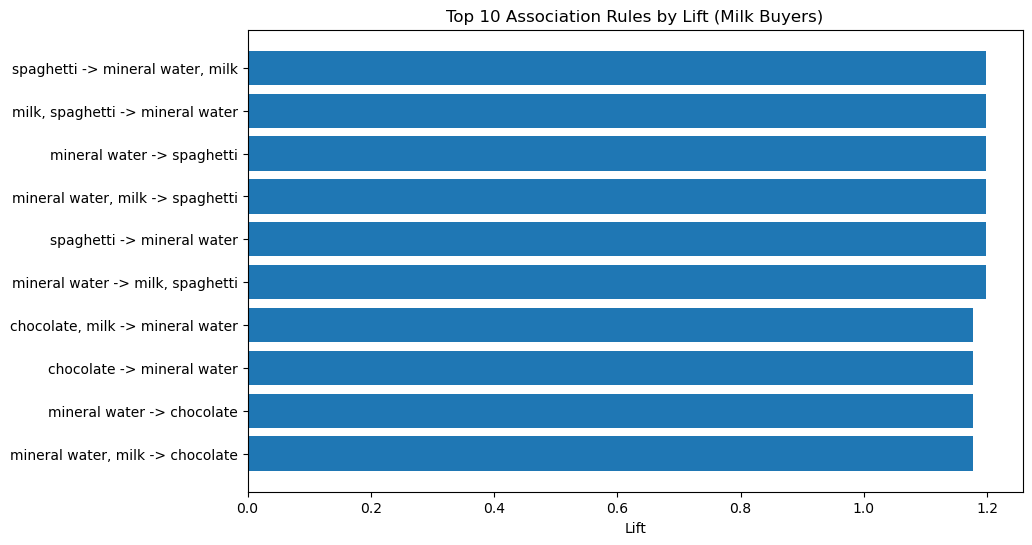

In [34]:
cat_df = basket_trans.loc[basket_trans['milk']==1]
frequent_itemsets = apriori(cat_df, min_support=0.1, use_colnames=True)  # Fixed typo here
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

# convert frozensets to strings for labeling
top_rules['antecedents_str'] = top_rules['antecedents'].apply(lambda x: ', '.join(list(x)))
top_rules['consequents_str'] = top_rules['consequents'].apply(lambda x: ', '.join(list(x)))

# create a bar chart
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_rules)), top_rules['lift'], tick_label=top_rules['antecedents_str'] + ' -> ' + top_rules['consequents_str'])
plt.title('Top 10 Association Rules by Lift (Milk Buyers)')
plt.xlabel('Lift')
plt.gca().invert_yaxis()
plt.show()

In [35]:
# Basic metrics about your dataset
print(f"Total transactions: {len(basket_trans)}")
print(f"Unique products: {len(basket_trans.columns)}")
print(f"Average basket size: {basket_trans.sum(axis=1).mean():.2f} items")
print(f"Total rules generated: {len(rules)}")

Total transactions: 7501
Unique products: 119
Average basket size: 3.91 items
Total rules generated: 60


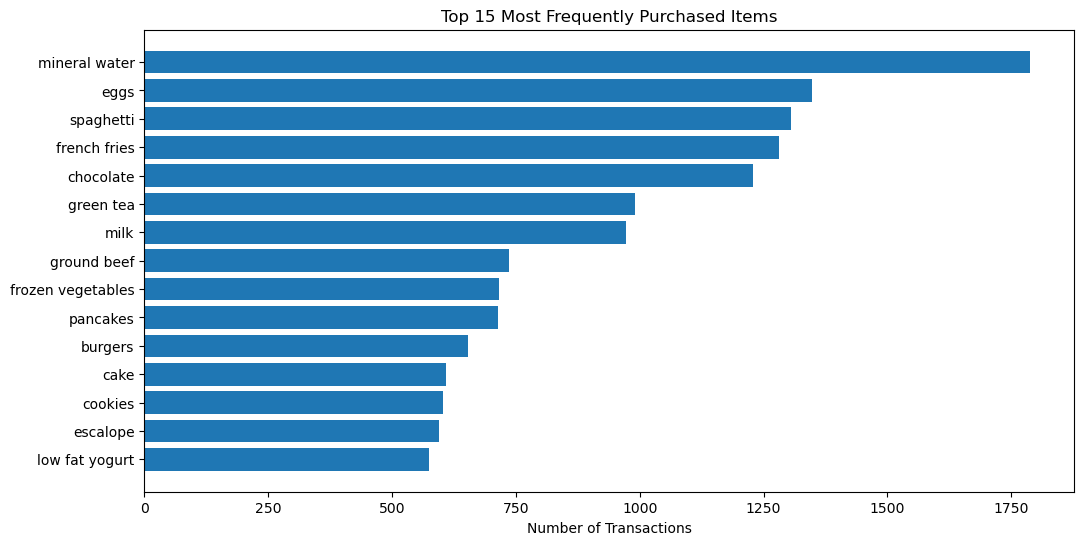

In [36]:
item_frequency = basket_trans.sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
plt.barh(range(len(item_frequency)), item_frequency.values)
plt.yticks(range(len(item_frequency)), item_frequency.index)
plt.xlabel('Number of Transactions')
plt.title('Top 15 Most Frequently Purchased Items')
plt.gca().invert_yaxis()
plt.show()

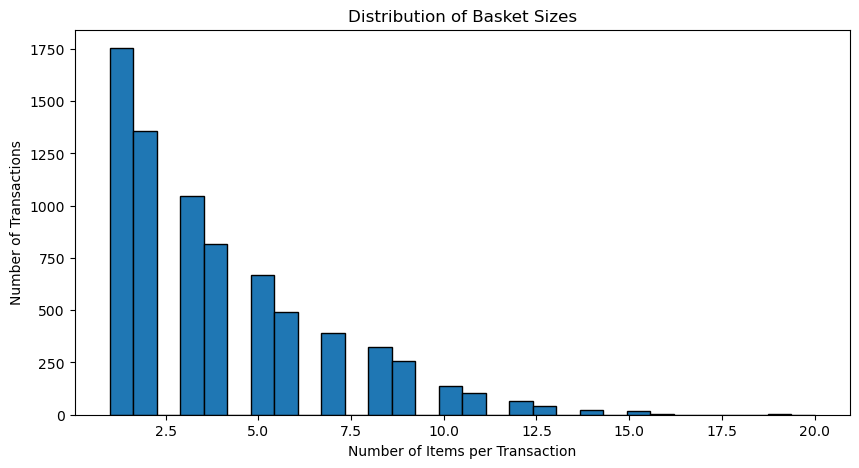

In [37]:
basket_sizes = basket_trans.sum(axis=1)

plt.figure(figsize=(10, 5))
plt.hist(basket_sizes, bins=30, edgecolor='black')
plt.xlabel('Number of Items per Transaction')
plt.ylabel('Number of Transactions')
plt.title('Distribution of Basket Sizes')
plt.show()

In [38]:
# Running apriori on ALL transactions
frequent_itemsets_all = apriori(basket_trans, min_support=0.01, use_colnames=True)

# Generate rules from ALL transactions
rules_all = association_rules(frequent_itemsets_all, metric="lift", min_threshold=1.0)

print(f"Total rules from all transactions: {len(rules_all)}")

# Now filter for rules involving milk
milk_rules = rules_all[
    (rules_all['antecedents'].apply(lambda x: 'milk' in x)) |
    (rules_all['consequents'].apply(lambda x: 'milk' in x))
]

# Filter for actionable rules
actionable_rules = milk_rules[
    (milk_rules['confidence'] > 0.3) &
    (milk_rules['lift'] > 1.5) &
    (milk_rules['antecedents'].apply(len) <= 2)
].sort_values('lift', ascending=False)

print(f"Actionable milk rules: {len(actionable_rules)}")
actionable_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

Total rules from all transactions: 406
Actionable milk rules: 11


,antecedents,consequents,support,confidence,lift
364,"(frozen vegetables, mineral water)",(milk),0.011065,0.309701,2.389991
252,(soup),(milk),0.015198,0.300792,2.321232
377,"(milk, ground beef)",(mineral water),0.011065,0.503030,2.110308
366,"(milk, frozen vegetables)",(mineral water),0.011065,0.468927,1.967236
330,"(chocolate, milk)",(spaghetti),0.010932,0.340249,1.954217
388,"(mineral water, milk)",(spaghetti),0.015731,0.327778,1.882589
332,"(milk, spaghetti)",(chocolate),0.010932,0.308271,1.881480
389,"(milk, spaghetti)",(mineral water),0.015731,0.443609,1.861024
324,"(chocolate, milk)",(mineral water),0.013998,0.435685,1.827780
349,"(milk, eggs)",(mineral water),0.013065,0.424242,1.779778


In [39]:
# Top 10 rules by lift from all transactions
top_rules_all = rules_all.sort_values('lift', ascending=False).head(10)
top_rules_all[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift
214,(herb & pepper),(ground beef),0.015998,0.323450,3.291994
215,(ground beef),(herb & pepper),0.015998,0.162822,3.291994
387,(ground beef),"(mineral water, spaghetti)",0.017064,0.173677,2.907928
382,"(mineral water, spaghetti)",(ground beef),0.017064,0.285714,2.907928
397,(olive oil),"(mineral water, spaghetti)",0.010265,0.155870,2.609786
396,"(mineral water, spaghetti)",(olive oil),0.010265,0.171875,2.609786
192,(frozen vegetables),(tomatoes),0.016131,0.169231,2.474464
193,(tomatoes),(frozen vegetables),0.016131,0.235867,2.474464
188,(shrimp),(frozen vegetables),0.016664,0.233209,2.446574
189,(frozen vegetables),(shrimp),0.016664,0.174825,2.446574


In [40]:
# Saving rules for reporting
rules.to_csv('association_rules_full.csv', index=False)
top_rules.to_csv('top_rules.csv', index=False)

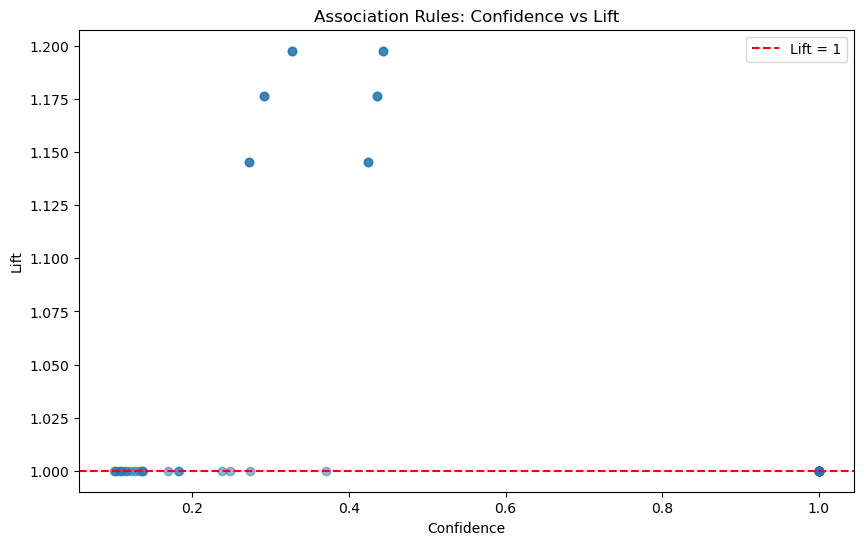

In [41]:
# Lift vs Confidence Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(rules['confidence'], rules['lift'], alpha=0.5)
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.title('Association Rules: Confidence vs Lift')
plt.axhline(y=1, color='r', linestyle='--', label='Lift = 1')
plt.legend()
plt.show()